<a href="https://colab.research.google.com/github/FilippoCasellini/2025_ML_EES/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assessing Hydrometereological Drivers In Alpine Catchments Using Interpretable Machine Learning**



The hydrological response of Alpine catchments is complex and non-linear,
as it depends on several interacting climatic and topographic factors.
Understanding how these factors interact is critical for water resource (i.e., hydropower) and risk management, as well as assessing the impacts of climate change on Alpine hydrology.
Machine learning offers a data-driven approach that can capture these complex and non-linear relationships.
For this project, the main objectives are:
*   to predict river flow based on meteorological and topographical predictors, and
*   to quantify and interpret the importance of these variables in different Alpine river basins.

# **Setup**

## **Import Libraries and Tools**

In this section, the libraries and tools applied in the analysis are imported.

In [16]:
# Files handling
import os
import glob

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from statsmodels.graphics.tsaplots import plot_acf

# Colab integration (Google Drive access)
from google.colab import drive
drive.mount('/content/drive')

# ML tools
from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from scipy.stats import randint

# Save model
import joblib
import pickle


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Import Data**

Here, the data is imported by specifying the base directory and the different paths. Since streamflow and glacier files are unique for each basin, *glob.glob* is employed, which allows multiple files to be selected together.

In [2]:
# Base directory where the dataset is stored on Google Drive
base_dir = "/content/drive/MyDrive/ML/project/data"

# Paths to different files
streamflow_path_pattern = f"{base_dir}/timeseries/observation_based/CAMELS_CH_obs_based_*.csv"
topo_path = f"{base_dir}/static_attributes/CAMELS_CH_topographic_attributes.csv"
glacier_path = f"{base_dir}/annual_timeseries/CAMELS_CH_annual_data_*.csv"

# Loading static attribute datasets
topo_df = pd.read_csv(topo_path, usecols=["gauge_id", "area", "elev_mean", "elev_min", "elev_max", "slope_mean"],comment="#", encoding='latin1')

# Loading all timeseries files
streamflow_files = glob.glob(streamflow_path_pattern)
glacier_files = glob.glob(glacier_path)

# Preview loaded files
print("Number of streamflow files loaded:", len(streamflow_files))
print("Number of glacier files loaded:", len(glacier_files))
print("Static topo attributes:", topo_df.shape)

Number of streamflow files loaded: 331
Number of glacier files loaded: 331
Static topo attributes: (331, 6)


## **Dataset Preparation**

After selecting the desired basins for the analysis, the files are filtered and merged into a single dataset specific to streamflow and glacier data.

In [3]:
# Selecting only the catchments of interest based on their IDs
catchments = ["2161", "2420","2351"]

In [4]:
# Filtering streamflow files by selected basins
selected_files_sf = [
    fp for fp in streamflow_files
    if os.path.basename(fp).split("_")[-1].split(".")[0] in catchments
]

# Reading and combining selected time series into one DataFrame
streamflow_list = []
for file_path in selected_files_sf:
    basin_id = os.path.basename(file_path).split("_")[-1].split(".")[0]
    df = pd.read_csv(file_path, usecols=["date", "discharge_vol(m3/s)", "precipitation(mm/d)", "temperature_min(degC)", "temperature_mean(degC)", "temperature_max(degC)", "rel_sun_dur(%)", "swe(mm)"], parse_dates=["date"])
    df["basin_id"] = basin_id
    streamflow_list.append(df)

streamflow_df = pd.concat(streamflow_list, ignore_index=True)

In [5]:
# Filtering glacier files by selected basins
selected_files_g = [
    g for g in glacier_files
    if os.path.basename(g).split("_")[-1].split(".")[0] in catchments
]

# Reading and combining selected time series into one DataFrame
glacier_list = []
for file_path in selected_files_g:
    basin_id = os.path.basename(file_path).split("_")[-1].split(".")[0]
    df = pd.read_csv(file_path, usecols=["year", "glac_area_ch(km2)", "glac_vol_ch(km3)", "glac_mass_ch(Mt)"], comment="#", parse_dates=["year"])
    df["basin_id"] = basin_id
    glacier_list.append(df)

glacier_df = pd.concat(glacier_list, ignore_index=True)

To allow a merge, it is therefore necessary to verify that the basin IDs in the datasets are strings. Furthermore, it is necessary to verify that the column names are the same.

In [6]:
# Making sure basin IDs are strings before merging
topo_df["gauge_id"] = topo_df["gauge_id"].astype(str)
glacier_df["basin_id"] = glacier_df["basin_id"].astype(str)
streamflow_df["basin_id"] = streamflow_df["basin_id"].astype(str)

In [7]:
# Renaming gauge_id to match basin_id
topo_df = topo_df.rename(columns={"gauge_id": "basin_id"})

In [8]:
# Keeping only selected basins for static data
topo_df = topo_df[topo_df["basin_id"].isin(catchments)]

To perform a consistent merge with the data, it is also necessary to align the datasets according to the time variables involved, and then merge them according to common columns such as basin IDs.

In [9]:
# Extracting year from streamflow_df (daily) for merging with glacier_df (annual)
streamflow_df['year'] = streamflow_df['date'].dt.year

# Ensuring year column in glacier_df is also an integer year for consistent merging
glacier_df['year'] = glacier_df['year'].dt.year

# Merging streamflow data with glacier data on basin_id and year
merged_time_series_df = pd.merge(streamflow_df, glacier_df, on=['basin_id', 'year'], how='left')

# Merging time series with static topographic attributes on basin_id
final_df = pd.merge(merged_time_series_df, topo_df, on='basin_id', how='left')

# Filtering the dataset for the 1999-2020 period
final_df = final_df[(final_df['year'] >= 1999)]

A common practice in preparing the dataset is to check the format of the columns, as well as a summary of the dataset and any possible missing values.

In [10]:
# Dataset overview
print("Shape:", final_df.shape)

# Column types
print("\nData types:")
print(final_df.dtypes)

# Summary of numerical columns
print("\nSummary:")
display(final_df.head())

# Missing value check
print("\nMissing values per column:")
print(final_df.isnull().sum())

Shape: (24108, 18)

Data types:
date                      datetime64[ns]
discharge_vol(m3/s)              float64
precipitation(mm/d)              float64
temperature_min(degC)            float64
temperature_mean(degC)           float64
temperature_max(degC)            float64
rel_sun_dur(%)                   float64
swe(mm)                          float64
basin_id                          object
year                               int32
glac_area_ch(km2)                float64
glac_vol_ch(km3)                 float64
glac_mass_ch(Mt)                 float64
area                             float64
elev_mean                        float64
elev_min                         float64
elev_max                         float64
slope_mean                       float64
dtype: object

Summary:


,date,discharge_vol(m3/s),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm),basin_id,year,glac_area_ch(km2),glac_vol_ch(km3),glac_mass_ch(Mt),area,elev_mean,elev_min,elev_max,slope_mean
6574,1999-01-01,0.340,0.16,-10.53,-9.45,-7.21,0.20,474.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6575,1999-01-02,0.336,2.15,-10.05,-8.52,-5.90,27.83,477.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6576,1999-01-03,0.341,14.53,-12.70,-9.87,-6.22,0.15,478.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6577,1999-01-04,0.342,0.21,-10.75,-4.62,-1.70,69.17,489.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6578,1999-01-05,0.339,0.00,-2.83,0.46,3.18,83.51,490.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32



Missing values per column:
date                      0
discharge_vol(m3/s)       0
precipitation(mm/d)       0
temperature_min(degC)     0
temperature_mean(degC)    0
temperature_max(degC)     0
rel_sun_dur(%)            0
swe(mm)                   0
basin_id                  0
year                      0
glac_area_ch(km2)         0
glac_vol_ch(km3)          0
glac_mass_ch(Mt)          0
area                      0
elev_mean                 0
elev_min                  0
elev_max                  0
slope_mean                0
dtype: int64


# **Preprocessing**

## **Data Preprocessing**

In this section, indices are derived from the variables in the dataset to accurately represent
seasonal dynamics
regulating runoff behavior as a function of temperature, solar radiation, and basin glaciation. Calendar variables have also been included to represent seasonality and
interannual variability without introducing data leakage.

In [11]:
final_df = final_df.sort_values(['basin_id', 'date'])

## Computing icemelt index

# Computing day of the year (doy)
final_df["doy"] = final_df["date"].dt.dayofyear
final_df["doy"] = final_df["doy"].astype(int)

# Computing glacier area fraction
final_df["glacier_area_frac"] = final_df["glac_area_ch(km2)"] / final_df["area"]

# Computing melt potential
final_df["pdd"] = np.maximum(final_df['temperature_mean(degC)'],0)
final_df["rad_fac"] = 1 + final_df["rel_sun_dur(%)"] / 100
final_df["melt_potential"] = final_df["pdd"] * final_df["rad_fac"]

# Computing melt seasonality according to climate-driven.
# The series is normalized to isolate the seasonal dynamics of melt within each year, ensuring that the index represents relative melt timing rather than absolute climatic magnitude
def normalize_series(x):
    rng = x.max() - x.min()
    if rng == 0:
        return np.zeros_like(x)
    return (x - x.min()) / rng

final_df["s_doy_year"] = (
    final_df
    .groupby(["basin_id", "year"])["melt_potential"]
    .transform(normalize_series)
)

final_df["s_doy_year"] = final_df["s_doy_year"].fillna(0)

# Computing the icemelt index
final_df["ice_melt_index_year"] = (
    final_df["melt_potential"] *
    final_df["glacier_area_frac"] *
    final_df["s_doy_year"])

# Visualizing final dataset after data preprocessing
final_df.head()


,date,discharge_vol(m3/s),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm),basin_id,year,...,elev_min,elev_max,slope_mean,doy,glacier_area_frac,pdd,rad_fac,melt_potential,s_doy_year,ice_melt_index_year
6574,1999-01-01,0.340,0.16,-10.53,-9.45,-7.21,0.20,474.0,2161,1999,...,1472.64,4088.8,23.32,1,0.604438,0.00,1.0020,0.000000,0.000000,0.000000
6575,1999-01-02,0.336,2.15,-10.05,-8.52,-5.90,27.83,477.0,2161,1999,...,1472.64,4088.8,23.32,2,0.604438,0.00,1.2783,0.000000,0.000000,0.000000
6576,1999-01-03,0.341,14.53,-12.70,-9.87,-6.22,0.15,478.0,2161,1999,...,1472.64,4088.8,23.32,3,0.604438,0.00,1.0015,0.000000,0.000000,0.000000
6577,1999-01-04,0.342,0.21,-10.75,-4.62,-1.70,69.17,489.0,2161,1999,...,1472.64,4088.8,23.32,4,0.604438,0.00,1.6917,0.000000,0.000000,0.000000
6578,1999-01-05,0.339,0.00,-2.83,0.46,3.18,83.51,490.0,2161,1999,...,1472.64,4088.8,23.32,5,0.604438,0.46,1.8351,0.844146,0.044497,0.022704


After calculating the indices, it is therefore essential that they are meaningful. The melt potential for a basin is thus plotted to verify their shape over the year.

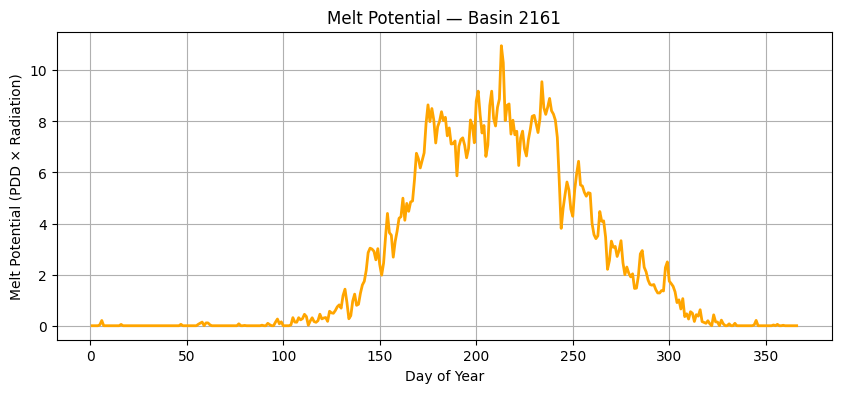

In [12]:
basin = "2161"
dfb = final_df[final_df["basin_id"] == basin].copy()
dfb["doy"] = dfb["date"].dt.dayofyear

# Climatology
mp_clim = dfb.groupby("doy")["melt_potential"].mean()

plt.figure(figsize=(10,4))
plt.plot(mp_clim.index, mp_clim.values, color="orange", linewidth=2)
plt.title(f"Melt Potential — Basin {basin}")
plt.xlabel("Day of Year")
plt.ylabel("Melt Potential (PDD × Radiation)")
plt.grid(True)
plt.show()


## **Predictor and Target Variable Selection**

After that, predictors and target variables must be selected.

In [13]:
# Selecting predictors
predictors = ["precipitation(mm/d)",
              "temperature_min(degC)",
              "temperature_mean(degC)",
              "temperature_max(degC)",
              "rel_sun_dur(%)",
              "swe(mm)",
              "glac_area_ch(km2)",
              "glac_vol_ch(km3)",
              "glac_mass_ch(Mt)",
              "area",
              "elev_mean",
              "elev_min",
              "elev_max",
              "slope_mean",
              "melt_potential",
              "s_doy_year",
              "ice_melt_index_year",
              "doy",
              "year",
              "glacier_area_frac"
]

# Defining X and y
X = final_df[predictors]
y = final_df["discharge_vol(m3/s)"]

## **Temporal Split**

Furthermore, to avoid data leakage and accurately represent the effect of climate change, a temporal split into train, validation, and test sets is performed according to a monthly sliding window (20-5-5). Therefore, verify that split is executed correctly by checking the sample sizes and, considering the monthly sliding windows, also the dates.

In [14]:
# Sorting data
data = final_df.sort_values(["basin_id", "date"]).reset_index(drop=True)

train_idx = []
val_idx = []
test_idx = []

# Looping over basins
for basin in data["basin_id"].unique():

    basin_df = data[data["basin_id"] == basin]

    # Looping over every year-month combination
    for (yr, mo), df_month in basin_df.groupby([basin_df["date"].dt.year,
                                                basin_df["date"].dt.month]):

        df_month = df_month.sort_values("date")
        n = len(df_month)

        # Standard 20–5–5 or adjusted for shorter months
        if n >= 30:
            n_train = 20
            n_val = 5
            n_test = 5
        elif n == 29:
            n_train = 19
            n_val = 5
            n_test = 5
        elif n == 28:
            n_train = 18
            n_val = 5
            n_test = 5

        # Extracting indices
        idx_train = df_month.iloc[:n_train].index
        idx_val   = df_month.iloc[n_train:n_train + n_val].index
        idx_test  = df_month.iloc[n_train + n_val:n_train + n_val + n_test].index

        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

# Creating again X and y from the 'data' DataFrame, which has the reset index.
X = data[predictors]
y = data["discharge_vol(m3/s)"]

# Final splitting
X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]


# Checking dimensions and correct splitting
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print(data.loc[train_idx, "date"].min(), data.loc[train_idx, "date"].max())
print(data.loc[val_idx,   "date"].min(), data.loc[val_idx,   "date"].max())
print(data.loc[test_idx,  "date"].min(), data.loc[test_idx,  "date"].max())



Train size: 15726
Validation size: 3960
Test size: 3960
1999-01-01 00:00:00 2020-12-20 00:00:00
1999-01-21 00:00:00 2020-12-25 00:00:00
1999-01-26 00:00:00 2020-12-30 00:00:00


## **Definition of evaluation metrics**

This section therefore defines the evaluation metrics employed to assess the performance of the models. Performance is therefore evaluated using Nash-Sutcliffe Efficiency (NSE), as this is a common metric in hydrological models, and RMSE, which assesses whether the forecast is similar to the observed values, particularly useful in peak flow conditions.

*   NSE 𝜖 ] − ∞, 1]. Higher values indicate a good prediction of simulated discharge according to observed discharge
*   RMSE 𝜖 [0, +∞[. RMSE quantifies the mean prediction error in [$𝑚^3/𝑠$]


In [15]:
# Definition of the function NSE to evaluate
def nse(obs, pred):
    return 1 - ((obs - pred)**2).sum() / ((obs - obs.mean())**2).sum()

# Definition of the function RMSE to evaluate
def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# **Modelling**

## **Baseline model - Multiple Linear Regression (MLR)**

Multiple Linear Regression (MLR) has been adopted as a baseline model to benchmark performance, as it assumes linear relationships between predictors and discharge. The input features have been divided following the same temporal split, as well as fitted and transformed with *StandardScaler()* on the train set and transformed on the validation and test sets to avoid data leakage.

In [18]:
# Dictionary to save results
baseline_results = {}

# Loop
for basin in catchments:

    print(f"Basin {basin} — MLR")

    # Selection of the data according to the basin
    mask_train = data.loc[train_idx, "basin_id"] == basin
    mask_val   = data.loc[val_idx,   "basin_id"] == basin
    mask_test  = data.loc[test_idx,  "basin_id"] == basin

    X_train_b = X_train[mask_train]
    y_train_b = y_train[mask_train]

    X_val_b   = X_val[mask_val]
    y_val_b   = y_val[mask_val]

    X_test_b  = X_test[mask_test]
    y_test_b  = y_test[mask_test]

    print(" Train samples:", len(X_train_b))
    print(" Val samples:  ", len(X_val_b))
    print(" Test samples: ", len(X_test_b))

    # Scaling, but fitting only on the train
    scaler = StandardScaler()
    X_train_b_scaled = scaler.fit_transform(X_train_b)
    X_val_b_scaled   = scaler.transform(X_val_b)
    X_test_b_scaled  = scaler.transform(X_test_b)

    # Instantiation of the Linear Regression Baseline
    lr_base = LinearRegression()

    lr_base.fit(X_train_b_scaled, y_train_b)

    # Predictions
    pred_train = lr_base.predict(X_train_b_scaled)
    pred_val   = lr_base.predict(X_val_b_scaled)
    pred_test  = lr_base.predict(X_test_b_scaled)

    # Evaluation Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_b, pred_train))
    val_rmse   = np.sqrt(mean_squared_error(y_val_b, pred_val))
    test_rmse  = np.sqrt(mean_squared_error(y_test_b, pred_test))

    # Results
    results = {
        "train_nse": nse(y_train_b, pred_train),
        "val_nse":   nse(y_val_b,   pred_val),
        "test_nse":  nse(y_test_b,  pred_test),
        "train_rmse": train_rmse,
        "val_rmse":   val_rmse,
        "test_rmse":  test_rmse,
        "model": lr_base
    }

    baseline_results[basin] = results

    print(" NSE Train:", results["train_nse"])
    print(" NSE Val:  ", results["val_nse"])
    print(" NSE Test: ", results["test_nse"])
    print(" RMSE Train:", results["train_rmse"])
    print(" RMSE Val:  ", results["val_rmse"])
    print(" RMSE Test: ", results["test_rmse"])

Basin 2161 — MLR
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.7176736302964712
 NSE Val:   0.7110904433813559
 NSE Test:  0.7146488566986253
 RMSE Train: 10.76204879018635
 RMSE Val:   11.375146382002121
 RMSE Test:  11.611800516615434
Basin 2420 — MLR
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.25778800352348397
 NSE Val:   0.20891237079203673
 NSE Test:  0.26927668644995906
 RMSE Train: 20.363368681678942
 RMSE Val:   16.268471864075117
 RMSE Test:  19.091602224566547
Basin 2351 — MLR
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.48662711225726096
 NSE Val:   0.5308883585674766
 NSE Test:  0.518422765656608
 RMSE Train: 8.208762094618372
 RMSE Val:   7.758669856930846
 RMSE Test:  8.369274300119857


## **Random Forest Regressor (RFR)**

In the following sections, the 3 models for each selected basin will be instantiated and the hyperparameters manually tuned for range identification and then automatically refined using *RandomizedSearchCV()* with the validation set. The final model will be tested using the optimal hyperparameters on the test set.  
Saving the final model is common practice as it allows to load it into new sessions without running the code multiple times, as it might be computational intensive.
Furthermore, to visualize performance on the test set, in hydrology modeling it is common to perform a comparison between the observed discharge with the predicted discharge by the model.

### **Random Forest - 2161**

#### Hyperparameters Tuning - Manual

In [68]:
# Dictionary to save results
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2161"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", 0.7, 0.5]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)


Best manual tuning NSE: 0.9116589599667207
Best params: (400, 10, 2, 0.7)


#### Hyperparameters Tuning - Automatic

In [72]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2161"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(350, 500),
    "max_depth": randint(5, 15),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", 0.5, 0.7]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.8902685345966326
Best parameters (automatic):
{'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 4, 'n_estimators': 413}


#### Final RFR Model

In [19]:
# Defining the best parameters for 2161 basin
best_params_2161 = {
    "n_estimators": 413,
    "max_depth": 7,
    "min_samples_leaf": 4,
    "max_features": 0.7
}

# RFR model for 2161
rf_final_2161 = RandomForestRegressor(
    **best_params_2161,
    n_jobs=-1,
    random_state=42
)

# Mask for train and validation
mask_train = (data.loc[train_idx, "basin_id"] == "2161")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2161")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2161")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2161.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2161.predict(X_train_b)
pred_val   = rf_final_2161.predict(X_val_b)
pred_test  = rf_final_2161.predict(X_test_b)

# Computing NSE and RMSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

rmse_train = rmse(y_train_b, pred_train)
rmse_val   = rmse(y_val_b,   pred_val)
rmse_test  = rmse(y_test_b,  pred_test)

print(f"NSE Train: {nse_train:.3f}   | RMSE Train: {rmse_train:.3f}")
print(f"NSE Val:   {nse_val:.3f}   | RMSE Val:   {rmse_val:.3f}")
print(f"NSE Test:  {nse_test:.3f}   | RMSE Test:  {rmse_test:.3f}")

NSE Train: 0.926   | RMSE Train: 5.524
NSE Val:   0.905   | RMSE Val:   6.524
NSE Test:  0.895   | RMSE Test:  7.055


In [20]:
# Saving the model
joblib.dump(rf_final_2161, "rf_model_2161.joblib")


['rf_model_2161.joblib']

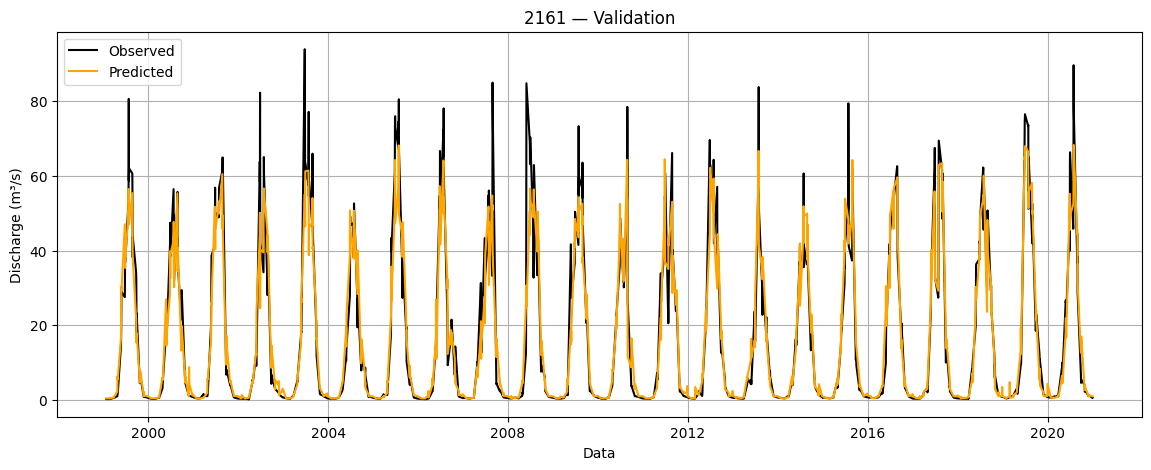

In [35]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2161"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2161 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()


### **Random Forest - 2420**

#### Hyperparameters Tuning - Manual

In [17]:
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2420"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [350, 400, 450],
    "max_depth": [15, 20, 25],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", 0.7, 0.8, 0.9]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)


Best manual tuning NSE: 0.5267320356338269
Best params: (400, 20, 4, 0.9)


#### Hyperparameters Tuning - Automatic

In [18]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2420"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(385, 415),
    "max_depth": randint(18, 25),
    "min_samples_leaf": randint(3, 6),
    "max_features": [0.9, 1]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.40429725226602103
Best parameters (automatic):
{'max_depth': 23, 'max_features': 0.9, 'min_samples_leaf': 5, 'n_estimators': 402}


#### Final RFR Model

In [18]:
# Defining the best parameters for 2420 basin
best_params_2420 = {
    "n_estimators": 402,
    "max_depth": 23,
    "min_samples_leaf": 5,
    "max_features": 0.9
}

# RFR model for 2420
rf_final_2420 = RandomForestRegressor(
    **best_params_2420,
    n_jobs=-1,
    random_state=42
)

# Mask for train and validation
mask_train = (data.loc[train_idx, "basin_id"] == "2420")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2420")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2420")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2420.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2420.predict(X_train_b)
pred_val   = rf_final_2420.predict(X_val_b)
pred_test  = rf_final_2420.predict(X_test_b)

# Computing NSE and RMSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

rmse_train = rmse(y_train_b, pred_train)
rmse_val   = rmse(y_val_b,   pred_val)
rmse_test  = rmse(y_test_b,  pred_test)

print(f"NSE Train: {nse_train:.3f}   | RMSE Train: {rmse_train:.3f}")
print(f"NSE Val:   {nse_val:.3f}   | RMSE Val:   {rmse_val:.3f}")
print(f"NSE Test:  {nse_test:.3f}   | RMSE Test:  {rmse_test:.3f}")

NSE Train: 0.766   | RMSE Train: 11.426
NSE Val:   0.524   | RMSE Val:   12.613
NSE Test:  0.519   | RMSE Test:  15.496


In [21]:
# Saving the model
joblib.dump(rf_final_2420, "rf_model_2420.joblib")

['rf_model_2420.joblib']

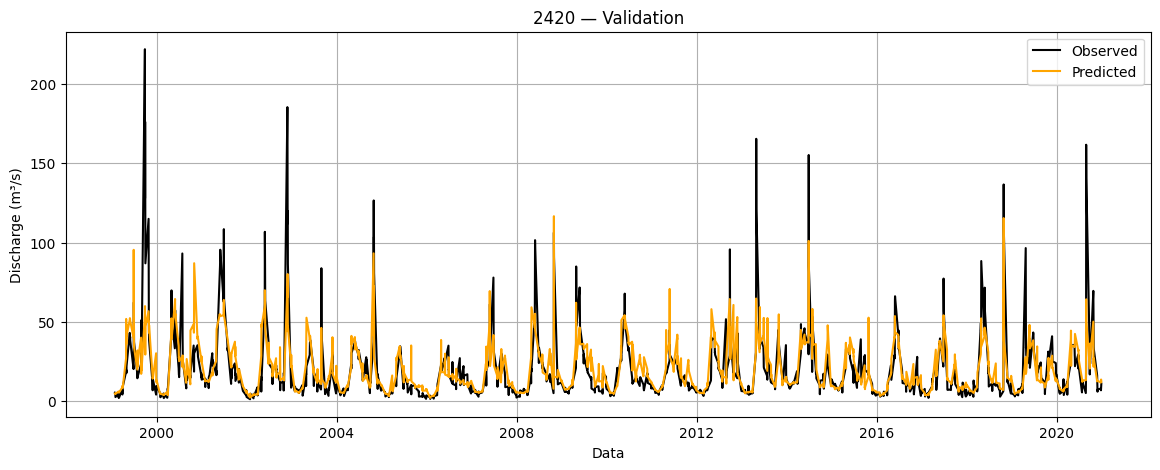

In [40]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2420"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2420 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

### **Random Forest - 2351**


#### Hyperparameters Tuning - Manual

In [22]:
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2351"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [200, 300, 350, 400],
    "max_depth": [10, 15, 20, 25],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", 0.7, 0.5]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)

Best manual tuning NSE: 0.7796953742382038
Best params: (200, 20, 3, 0.5)


#### Hyperparameters Tuning - Automatic

In [23]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2351"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(175, 250),
    "max_depth": randint(18, 23),
    "min_samples_leaf": randint(1, 4),
    "max_features": [0.3, 0.4, 0.5, 0.6]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.628775575615581
Best parameters (automatic):
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 216}


#### Final RFR Model

In [17]:
# Defining the best parameters for 2351 basin
best_params_2351 = {
    "n_estimators": 216,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "max_features": 0.5
}

# RFR model for 2351
rf_final_2351 = RandomForestRegressor(
    **best_params_2351,
    n_jobs=-1,
    random_state=42
)

# Mask for the subsets
mask_train = (data.loc[train_idx, "basin_id"] == "2351")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2351")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2351")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2351.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2351.predict(X_train_b)
pred_val   = rf_final_2351.predict(X_val_b)
pred_test  = rf_final_2351.predict(X_test_b)

# Computing NSE and RMSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

rmse_train = rmse(y_train_b, pred_train)
rmse_val   = rmse(y_val_b,   pred_val)
rmse_test  = rmse(y_test_b,  pred_test)

print(f"NSE Train: {nse_train:.3f}   | RMSE Train: {rmse_train:.3f}")
print(f"NSE Val:   {nse_val:.3f}   | RMSE Val:   {rmse_val:.3f}")
print(f"NSE Test:  {nse_test:.3f}   | RMSE Test:  {rmse_test:.3f}")

NSE Train: 0.904   | RMSE Train: 3.556
NSE Val:   0.779   | RMSE Val:   5.330
NSE Test:  0.713   | RMSE Test:  6.464


In [22]:
# Saving the model
joblib.dump(rf_final_2351, "rf_model_2351.joblib")

['rf_model_2351.joblib']

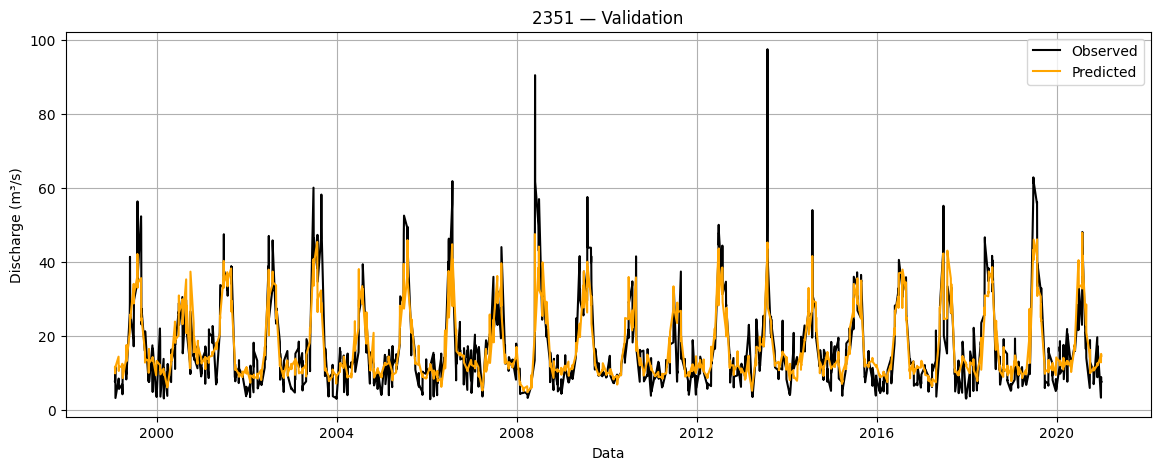

In [43]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2351"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2351 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

In this code cell, the three time series graphs are simply combined for a cleaner display and to create the image for the report.

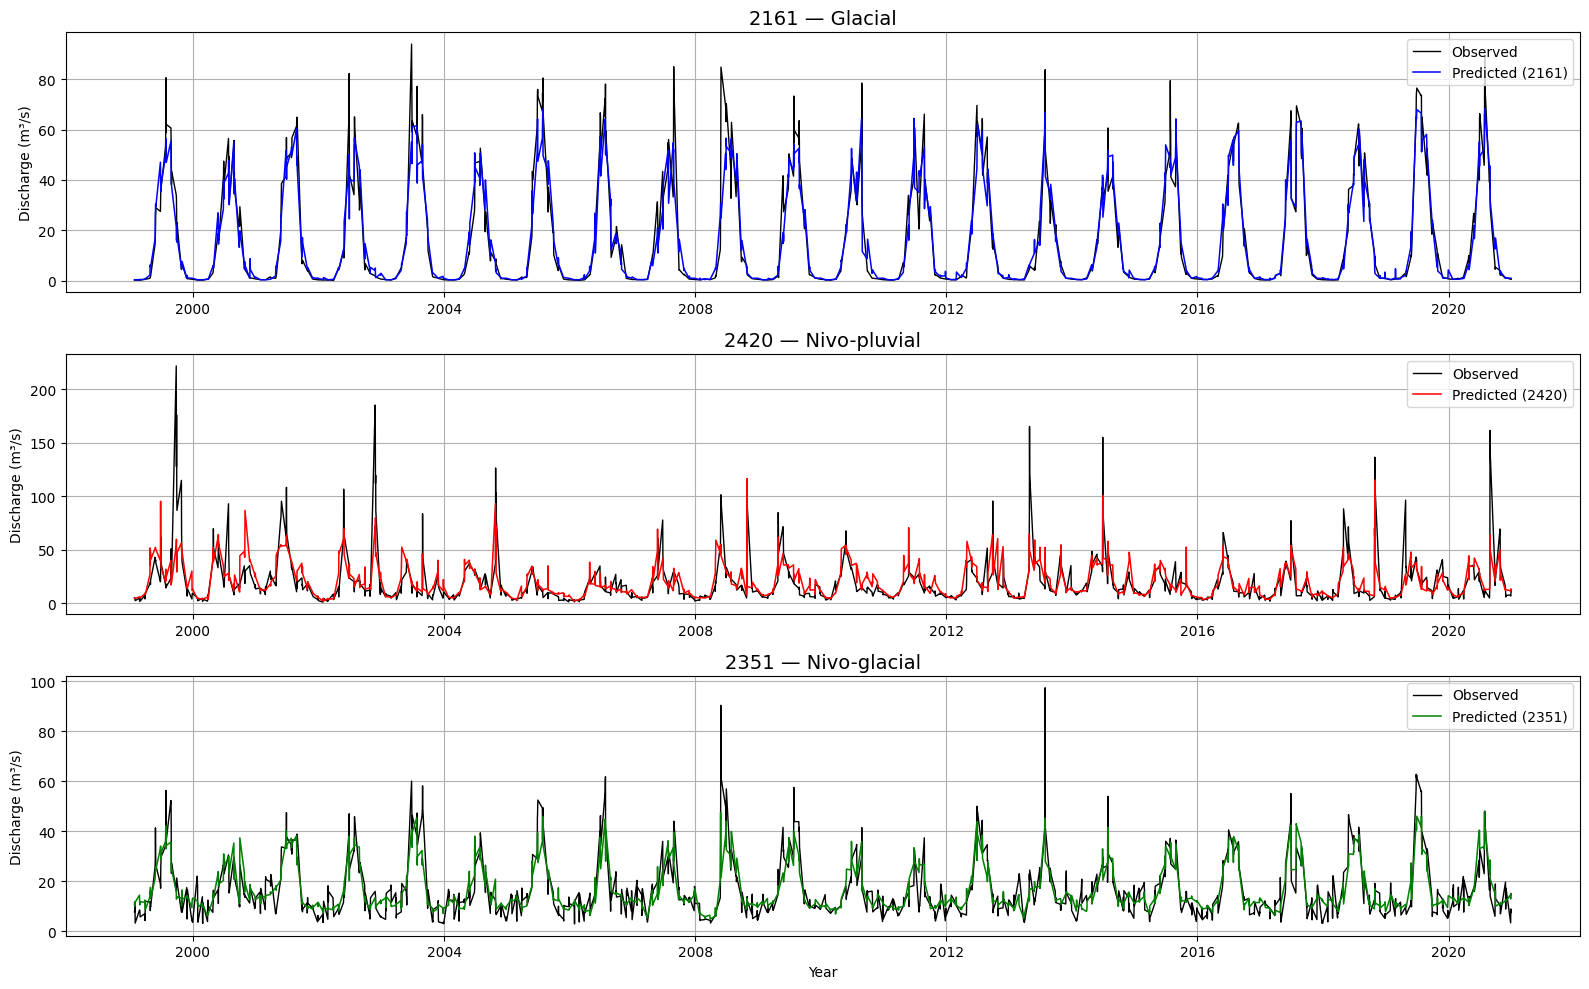

In [29]:
catchments = ["2161", "2420", "2351"]

model_files = {
    "2161": "rf_model_2161.joblib",
    "2420": "rf_model_2420.joblib",
    "2351": "rf_model_2351.joblib"
}

titles = {
    "2161": "2161 — Glacial",
    "2420": "2420 — Nivo-pluvial",
    "2351": "2351 — Nivo-glacial"
}

basin_colors = {
    "2161": "blue",
    "2420": "red",
    "2351": "green"
}

plt.figure(figsize=(16, 10))

for i, basin in enumerate(catchments, start=1):

    model = joblib.load(model_files[basin])

    mask_test = (data.loc[test_idx, "basin_id"] == basin)
    X_test_b = X_test[mask_test]
    y_test_b = y_test[mask_test]

    pred_test = model.predict(X_test_b)
    dates_test = data.loc[test_idx, "date"][mask_test]

    df_plot = pd.DataFrame({
        "date": dates_test.values,
        "obs": y_test_b.values,
        "pred": pred_test
    }).sort_values("date")

    ax = plt.subplot(3, 1, i)

    ax.plot(
        df_plot["date"], df_plot["obs"],
        label="Observed",
        color="black", linewidth=1
    )

    ax.plot(
        df_plot["date"], df_plot["pred"],
        label=f"Predicted ({basin})",
        color=basin_colors[basin], linewidth=1.1
    )

    ax.set_title(titles[basin], fontsize=14)
    ax.set_ylabel("Discharge (m³/s)")
    ax.grid(True)
    ax.legend(loc="upper right")

    if i == 3:
        ax.set_xlabel("Year")

plt.tight_layout()
plt.show()



# **Evaluation and Interpretation**

## **Cross-Transfer Matrix**


To assess RFR models generalization and compare the catchments, a cross-basin evaluation has been performed according to NSE scores. The previously created models for each basin are loaded and tested on the other two basins using NSE. This process is automated within a loop. A generalization score has then been calculated to determine which basin generalizes best.

       2161   2420   2351
2161  0.916 -0.622 -0.557
2420 -0.225  0.699 -2.763
2351  0.515  0.087  0.847


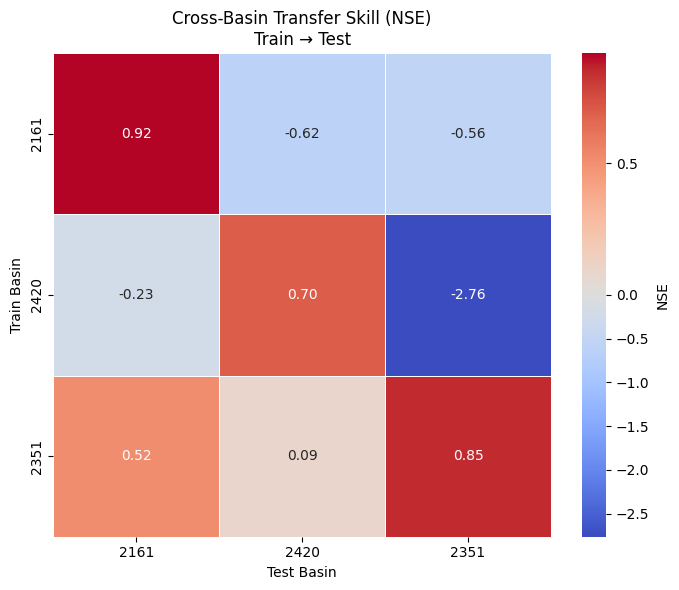

Model generalization
2351: 0.483
2161: -0.087
2420: -0.763


In [32]:
# Matrix cross-basin
cross_matrix = pd.DataFrame(
    index=catchments,
    columns=catchments,
    dtype=float
)

# Loop
for train_basin in catchments:

    # Load final RF model for the basins
    model = joblib.load(f"rf_model_{train_basin}.joblib")

    # Loop to assess the generalization
    for test_basin in catchments:

        # Creating a mask according to the basin for the test set
        mask = (data["basin_id"] == test_basin)
        X_y = X[mask]
        y_y = y[mask]

        # Predicting
        pred_y = model.predict(X_y)

        # NSE
        cross_nse = nse(y_y, pred_y)

        cross_matrix.loc[train_basin, test_basin] = cross_nse

print(cross_matrix.round(3))


# Matrix NSE cross-basin
nse_df = cross_matrix.astype(float)

plt.figure(figsize=(7,6))

# Normalization centering the colormap on NSE=0
norm = TwoSlopeNorm(
    vmin=nse_df.values.min(),
    vcenter=0,
    vmax=nse_df.values.max()
)

# Creating the heatmap
sns.heatmap(
    nse_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    norm=norm,
    linewidths=0.5,
    cbar_kws={"label": "NSE"}
)

plt.title("Cross-Basin Transfer Skill (NSE)\nTrain → Test")
plt.xlabel("Test Basin")
plt.ylabel("Train Basin")
plt.tight_layout()
plt.show()

# Generalization score
generalization_score = nse_df.mean(axis=1).sort_values(ascending=False)

print("Model generalization")
for basin, score in generalization_score.items():
    print(f"{basin}: {score:.3f}")


## **Feature Importance**

Feature importance (FI) has been applied to individual basins to interpret key drivers of the different hydrological regimes.
The basins and their respective models have therefore been recalled. Subsequently, only the dynamic variables that contribute to explaining the differences in regimes on a daily scale have been selected, as the prediction is for daily runoff. A bar plot has been created to facilitate the visualization of the drivers for each basin.

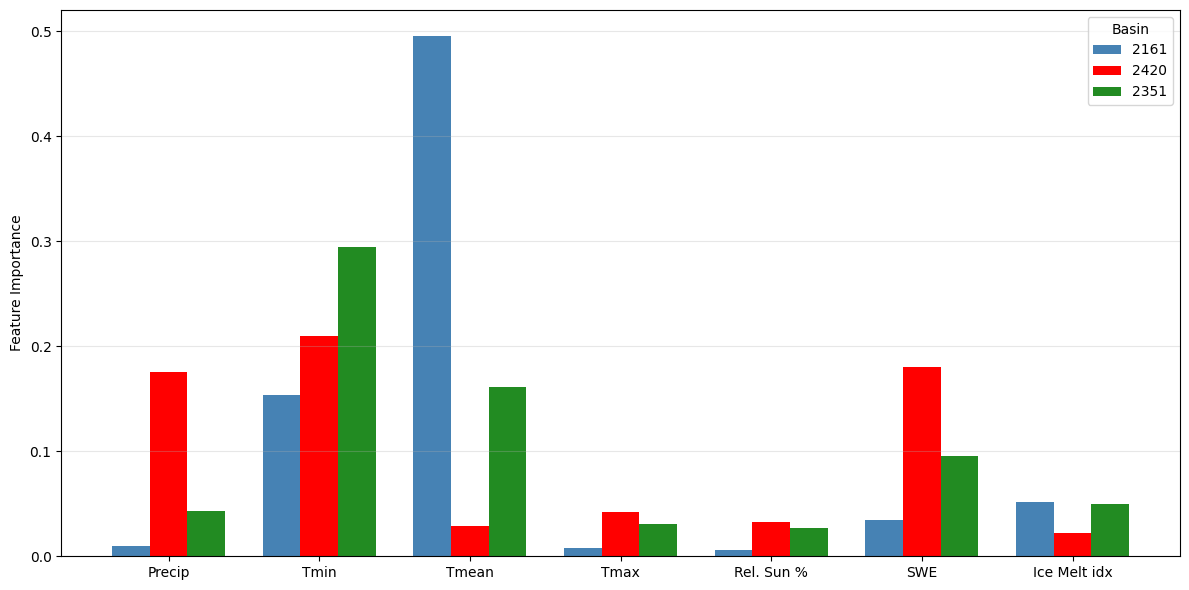

In [35]:
# Basins and model files
basins = ["2161", "2420", "2351"]
model_files = {
    "2161": "rf_model_2161.joblib",
    "2420": "rf_model_2420.joblib",
    "2351": "rf_model_2351.joblib"
}

# Dynamic features
dynamic_time = [
    "precipitation(mm/d)",
    "temperature_min(degC)",
    "temperature_mean(degC)",
    "temperature_max(degC)",
    "rel_sun_dur(%)",
    "swe(mm)",
    "ice_melt_index_year"
]

# Collect dynamic FI for all basins
fi_all = pd.DataFrame(index=dynamic_time, columns=basins)

rename_map = {
    "precipitation(mm/d)": "Precip",
    "temperature_min(degC)": "Tmin",
    "temperature_mean(degC)": "Tmean",
    "temperature_max(degC)": "Tmax",
    "rel_sun_dur(%)": "Rel. Sun %",
    "swe(mm)": "SWE",
    "ice_melt_index_year": "Ice Melt idx"
}


# Computing FI
for basin in basins:
    model = joblib.load(model_files[basin])
    fi = pd.DataFrame({
        "feature": predictors,
        "importance": model.feature_importances_
    })
    fi_dyn = fi[fi["feature"].isin(dynamic_time)].set_index("feature")
    fi_all[basin] = fi_dyn.loc[dynamic_time, "importance"]

# Plot grouped bar chart
plt.figure(figsize=(12, 6))

x = np.arange(len(dynamic_time))
width = 0.25

plt.bar(x - width, fi_all["2161"], width=width, label="2161", color="steelblue")
plt.bar(x,         fi_all["2420"], width=width, label="2420", color="red")
plt.bar(x + width, fi_all["2351"], width=width, label="2351", color="forestgreen")

plt.xticks(x, [rename_map[v] for v in dynamic_time], rotation=0, ha="center")
plt.ylabel("Feature Importance")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Basin", fontsize=10)

plt.tight_layout()
plt.show()